In [46]:
import os
from music21 import note, stream, tempo, bar, clef, converter, tempo
import time
from pathlib import Path
from pythonosc.udp_client import SimpleUDPClient

In [4]:
ASSETS_ABSPATH = Path(os.environ["ASSETS_ABSPATH"])
FILE_ABSPATH = ASSETS_ABSPATH / "MusicXML" / "Muse" / "Hysteria intro.musicxml"

In [6]:
client = SimpleUDPClient(address="192.168.1.151", port=57121)

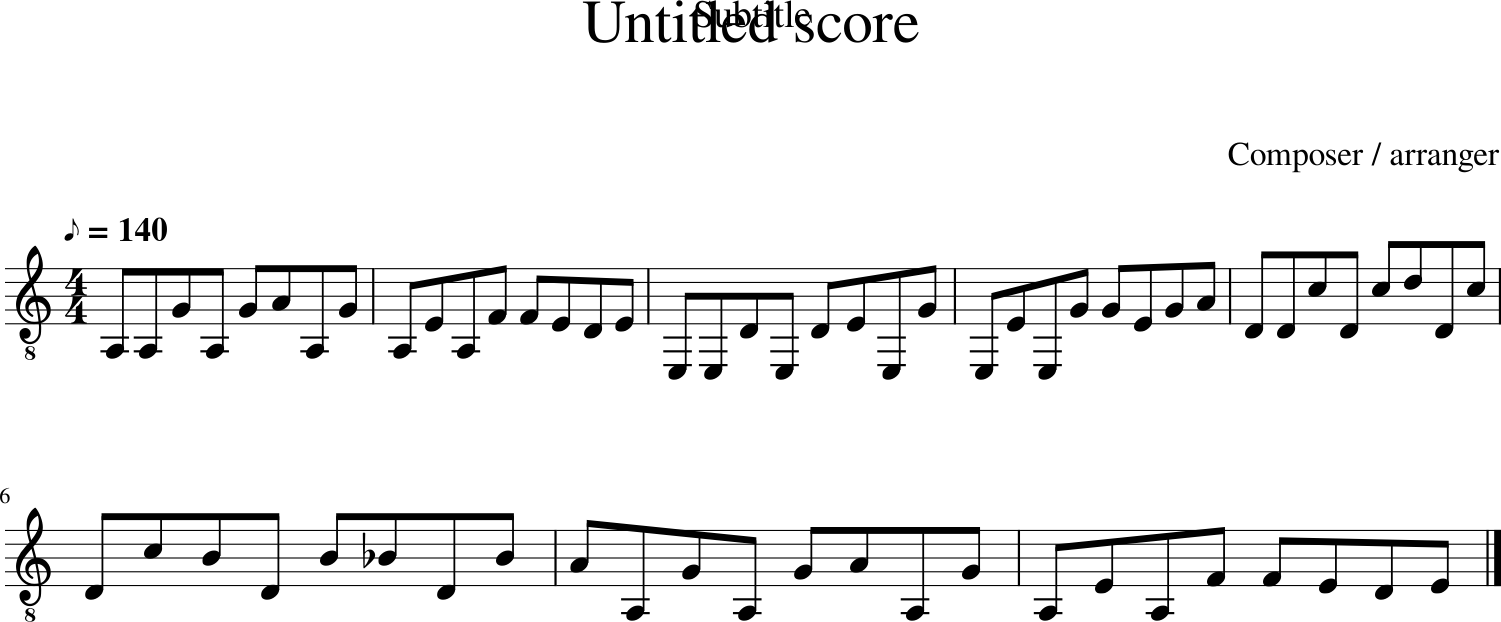

In [9]:
score = converter.parse(FILE_ABSPATH)
score.show()

In [ ]:
osc_endpoint = "/bass"

from collections import defaultdict

elems_by_offset = defaultdict(list)
for n in score.flatten():
    elems_by_offset[n.offset].append(n)
sorted_elems_by_offset = sorted(elems_by_offset.keys())


def play(osc_endpoint, sorted_elems_by_offset):
    current_freq = 1
    for i in range(0, 8):
        prev_offset = -sorted_elems_by_offset[1]
        for offset in sorted_elems_by_offset:
            offset_delta = offset - prev_offset
            prev_offset = offset
            notes = elems_by_offset[offset]
            for n in notes:
                match n:
                    case note.Note():
                        message = [
                            n.pitch.midi,
                            n.seconds,
                            n.volume.velocity or 90,
                        ]
                        client.send_message(osc_endpoint, message)
                        time.sleep(offset_delta * current_freq)
                    case tempo.MetronomeMark():
                        current_freq = 60 / n.number
                    case note.Unpitched():
                        message_common = [
                            n.seconds,
                            n.volume.velocity or 90,
                        ]
                        match n.displayName:
                            # Kick
                            case "F4":
                                client.send_message(
                                    osc_endpoint, [36, *message_common]
                                )
                            # Ride
                            case "F5":
                                client.send_message(
                                    osc_endpoint, [53, *message_common]
                                )
                                # Tambourine
                                client.send_message(
                                    osc_endpoint, [3, *message_common]
                                )
                            # Ride crash
                            case "A5":
                                client.send_message(
                                    osc_endpoint, [59, *message_common]
                                )
                            # Snare
                            case "C5":
                                client.send_message(
                                    osc_endpoint, [38, *message_common]
                                )


play("/bass", sorted_elems_by_offset)

KeyboardInterrupt: 